In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [84]:
import os
os.listdir()

['.ipynb_checkpoints', 'data.csv', 'House_price_Prediction.ipynb']

In [85]:
df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [86]:
# ==========================================
# Data Inspection and Cleaning
# ==========================================

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nPrice Statistics:")
print(df["price"].describe())

print("\nZero or Negative Prices:", (df["price"] <= 0).sum())

Dataset Shape: (4600, 18)

Missing Values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Duplicate Rows: 0

Data Types:
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

Price Statistics:
count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00

In [87]:
# ==========================================
# Remove Invalid Price Records
# ==========================================

before = df.shape[0]

df = df[df["price"] > 0].copy()

after = df.shape[0]

print("Rows before cleaning:", before)
print("Rows removed:", before - after)
print("Rows after cleaning:", after)
print("Minimum price after cleaning:", df["price"].min())

Rows before cleaning: 4600
Rows removed: 49
Rows after cleaning: 4551
Minimum price after cleaning: 7800.0


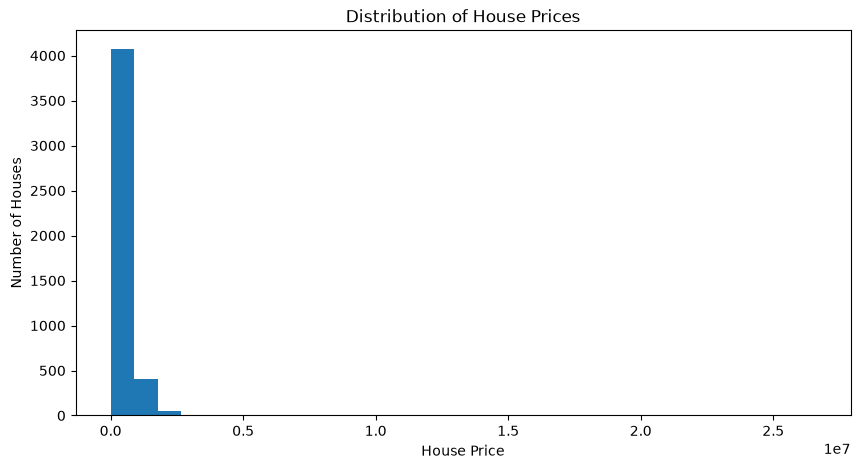

In [88]:
plt.figure(figsize=(10, 5))

plt.hist(y, bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")

plt.show()

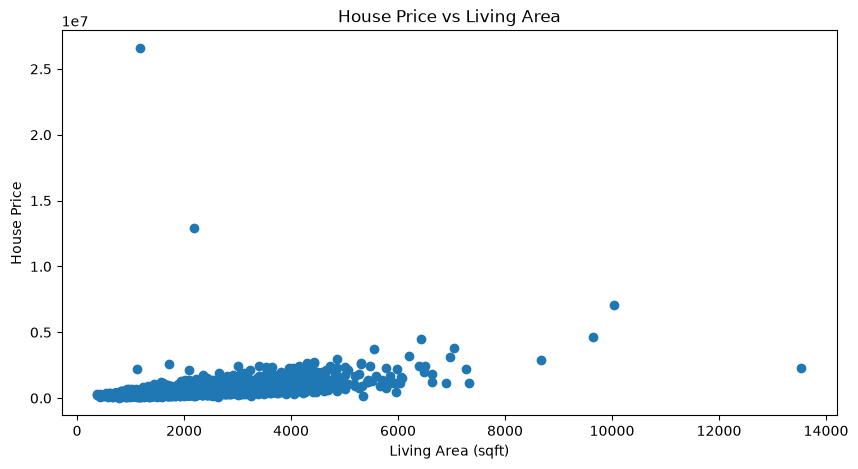

In [89]:
plt.figure(figsize=(10, 5))

plt.scatter(X["sqft_living"], y)

plt.title("House Price vs Living Area")
plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")

plt.show()

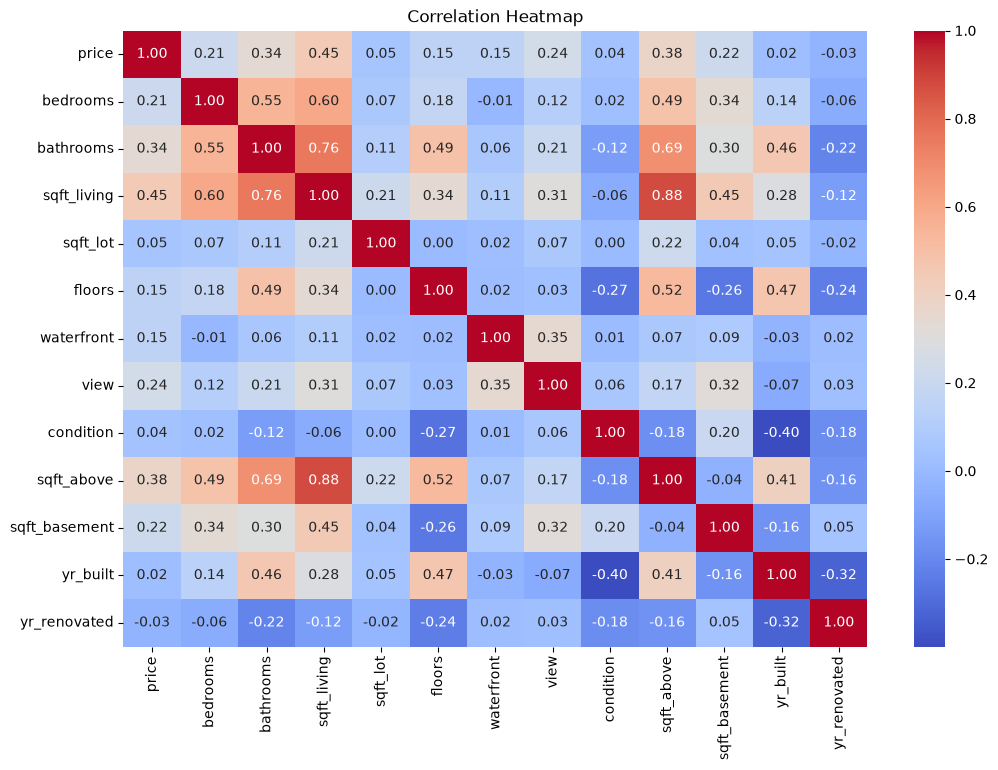

In [90]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

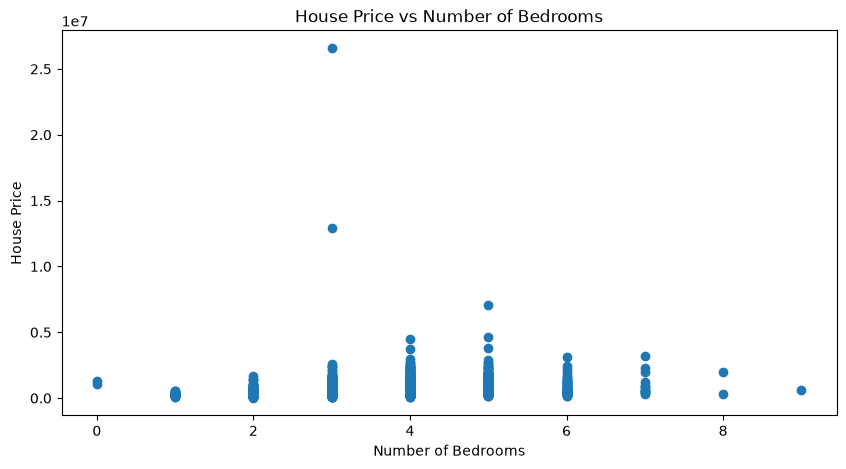

In [91]:
plt.figure(figsize=(10, 5))

plt.scatter(df["bedrooms"], df["price"])

plt.title("House Price vs Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price")

plt.show()

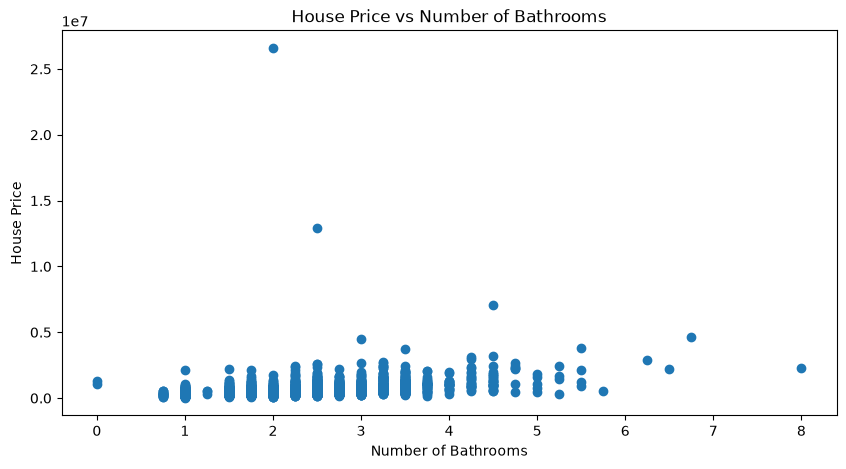

In [92]:
plt.figure(figsize=(10, 5))

plt.scatter(df["bathrooms"], df["price"])

plt.title("House Price vs Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("House Price")

plt.show()

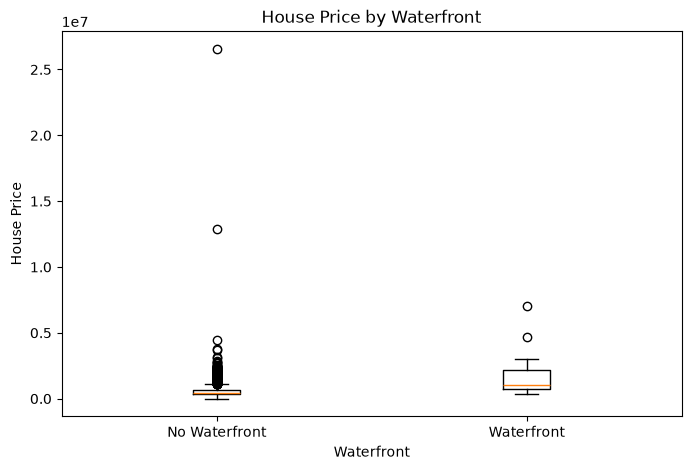

In [93]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [df[df["waterfront"] == 0]["price"],
     df[df["waterfront"] == 1]["price"]],
    tick_labels=["No Waterfront", "Waterfront"]
)

plt.title("House Price by Waterfront")
plt.xlabel("Waterfront")
plt.ylabel("House Price")

plt.show()

In [94]:
# ==========================================
# Define Features and Target
# ==========================================

# Drop columns that are not useful for prediction
# Street has very high cardinality, while country has only one value.
X = df.drop(columns=["price", "date", "street", "country"])

y = df["price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("price")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip']

Target:
price

Feature shape: (4551, 14)
Target shape: (4551,)


In [95]:
# ==========================================
# Feature Preprocessing / Encoding
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "str"]).columns

print("Numerical features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Feature preprocessing created successfully.")

Numerical features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']
Categorical features: ['city', 'statezip']
Feature preprocessing created successfully.


In [96]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3640, 14)
Testing set shape: (911, 14)


In [97]:
# ==========================================
# Feature Preprocessing
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify numerical and categorical features
numeric_features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]

categorical_features = [
    "city",
    "statezip"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 12
Categorical features: 2


In [98]:
# ==========================================
# Linear Regression
# ==========================================

from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression model trained successfully.")
print("Number of predictions:", len(lr_pred))

Linear Regression model trained successfully.
Number of predictions: 911


In [99]:
# ==========================================
# Decision Tree Regression
# ==========================================

from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42,
        max_depth=10
    ))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree model trained successfully.")
print("Number of predictions:", len(dt_pred))

Decision Tree model trained successfully.
Number of predictions: 911


In [100]:
# ==========================================
# Random Forest Regression
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")
print("Number of predictions:", len(rf_pred))

Random Forest model trained successfully.
Number of predictions: 911


,Feature,Importance
2,num__sqft_living,0.496447
3,num__sqft_lot,0.089445
10,num__yr_built,0.079361
8,num__sqft_above,0.063305
1,num__bathrooms,0.033648
128,cat__statezip_WA 98199,0.024523
57,cat__statezip_WA 98004,0.022225
73,cat__statezip_WA 98031,0.018159
9,num__sqft_basement,0.017764
11,num__yr_renovated,0.017016


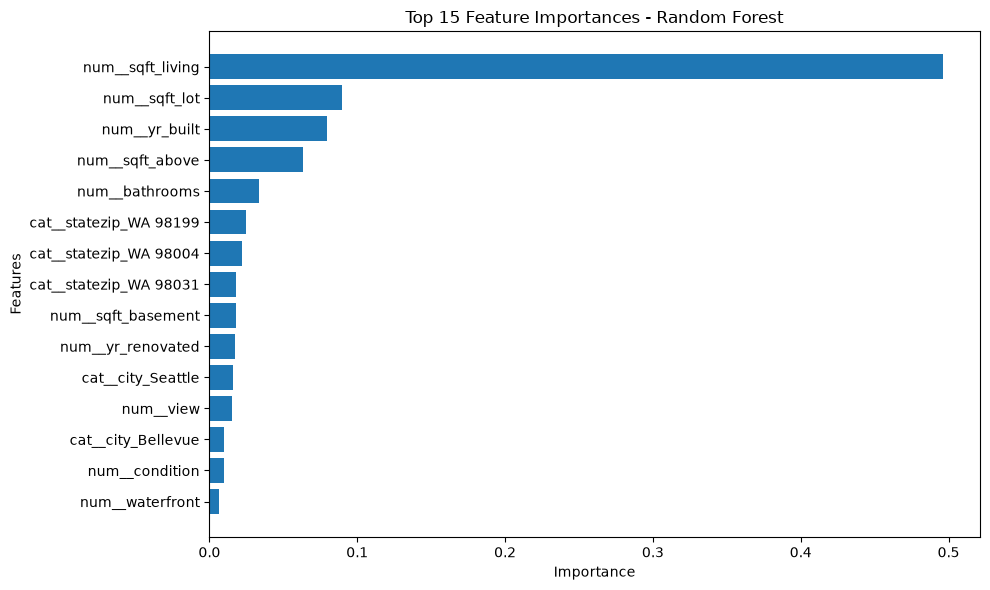

In [101]:
# ==========================================
# Random Forest Feature Importance
# ==========================================

fitted_preprocessor = rf_model.named_steps["preprocessor"]
fitted_rf = rf_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top 15 features
top_features = feature_importance.head(15)

display(top_features)

# Plot top 15 features
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [102]:
# ==========================================
# Model Evaluation
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    print(f"\n{name}")
    print("-" * 30)
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R² Score:", r2)

    return mae, mse, rmse, r2


lr_metrics = evaluate_model("Linear Regression", y_test, lr_pred)
dt_metrics = evaluate_model("Decision Tree", y_test, dt_pred)
rf_metrics = evaluate_model("Random Forest", y_test, rf_pred)


Linear Regression
------------------------------
MAE: 139638.89258389137
MSE: 54014061532.385895
RMSE: 232409.25440348947
R² Score: 0.6369300283324701

Decision Tree
------------------------------
MAE: 149182.9492352454
MSE: 90211328447.41382
RMSE: 300352.0075634818
R² Score: 0.39362041042118967

Random Forest
------------------------------
MAE: 121307.26588266848
MSE: 102332573767.66599
RMSE: 319894.62916352
R² Score: 0.31214421570177464


In [103]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_metrics[0],
        dt_metrics[0],
        rf_metrics[0]
    ],
    "MSE": [
        lr_metrics[1],
        dt_metrics[1],
        rf_metrics[1]
    ],
    "RMSE": [
        lr_metrics[2],
        dt_metrics[2],
        rf_metrics[2]
    ],
    "R² Score": [
        lr_metrics[3],
        dt_metrics[3],
        rf_metrics[3]
    ]
})

comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,139638.892584,5.401406e+10,232409.254403,0.636930
1,Decision Tree,149182.949235,9.021133e+10,300352.007563,0.393620
2,Random Forest,121307.265883,1.023326e+11,319894.629164,0.312144


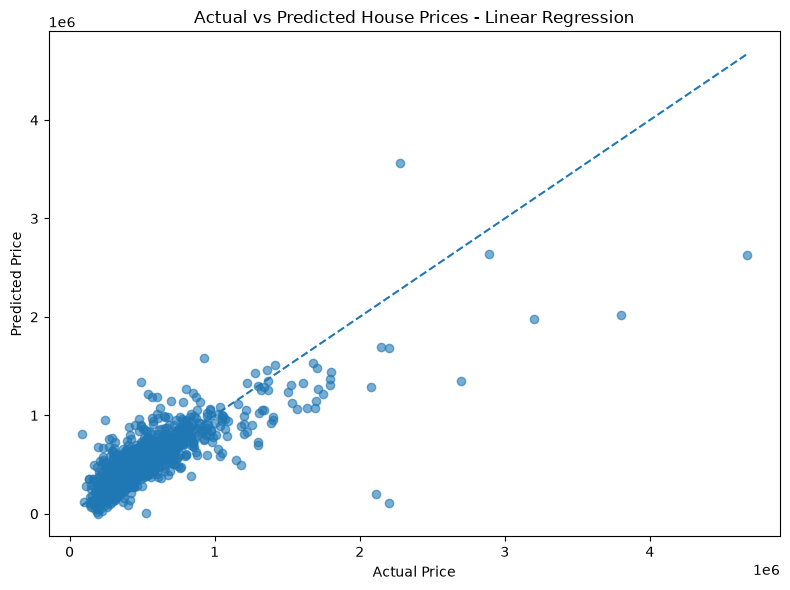

In [106]:
# ==========================================
# Actual vs Predicted Prices
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices - Linear Regression")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

In [107]:
# ==========================================
# Best Overall Model
# ==========================================

best_model = comparison.loc[
    comparison["R² Score"].idxmax(),
    "Model"
]

print("Best Overall Model:", best_model)

Best Overall Model: Linear Regression


## Final Model Performance

Three regression models were trained and evaluated for house price prediction: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Based on the test-set results, Linear Regression was selected as the final model because it achieved the highest R² Score and the lowest RMSE.

| Model | MAE | MSE | RMSE | R² Score |
|---|---:|---:|---:|---:|
| Linear Regression | 139638.89 | 5.4014e+10 | 232409.25 | 0.6369 |
| Decision Tree | 149182.95 | 9.0211e+10 | 300352.01 | 0.3936 |
| Random Forest | 121307.27 | 1.0233e+11 | 319894.63 | 0.3121 |

**Final selected model: Linear Regression**

The Random Forest model had the lowest MAE, but Linear Regression performed better overall based on R² Score and RMSE.